1. Greeting graph

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph
from IPython.display import Image, display

In [2]:
# типа просто обёртка на тайпдиктом
class AgentState(TypedDict):
    message : str
# важно везде в тулзах использовать докстринги, они нужны ллм. этот тул принимает стейт и модифицирует только
# его поля - важно для безопасности и интерпретируемости при параллельном исполнении.
def greeting_node(state : AgentState) -> dict:
    """ A simple node to greet a user. """
    new_message = "Hey, " + state['message'] + ", wassup?\n"
    return {"message": new_message}

In [3]:
#передаём структуру графа с хранящямися полями
graph = StateGraph(AgentState)

In [4]:
# добавлять ноды можно с названиями, которые не читаются ллмкой, но читаются разрабом. ещё один параметр
# сама функция как объект
# добавляем все ноды, какие будут. порядок определяется потом
graph.add_node("greeter", greeting_node)

graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

In [5]:
# делаем граф исполняемым - компилируем его
app = graph.compile()

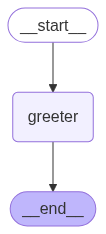

In [6]:
# можно провернуть фарш обратно и посмотреть структуру уже скомпилированного графа. для этого 
# обращаемся к скомпилированному графу, берём из него сам граф и вызваем вспомогательную функцию
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
# вызов приложения в целом, а не только одной его ноды - инвоук
# причём, это сделано удобно для ллм, чтобы поля вызывались как словари
res = app.invoke({"message" : "Artyom"})

In [8]:
res['message']

'Hey, Artyom, wassup?\n'

2. A graph with multiple fields

In [9]:
# from langgraph.graph import StateGraph

# Поля можно объявлять прямо тут, их произвольное количество, типы тоже произвольные
class AgentState(TypedDict):
    values : list[int] = [0]
    name : str = 'Noname'
    result : str

# Опять же, модифицируем только поля, а не само состояние напрямую
def process_value(state : AgentState) -> dict:
    """This function handles multiple differrent inputs"""
    modified_result = f"Hi there {state['name']}! Your sum = {sum(state['values'])}."
    return {'result' : modified_result}

graph = StateGraph(AgentState)

graph.add_node("processor", process_value)

graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()
# Вызываем со всеми полями.
res = app.invoke({'name' : 'Artyom', 'values' : [1, 2, 3, 4, 5]})
res['result']


'Hi there Artyom! Your sum = 15.'

In [10]:
# Нельзя вызывать неполный дикт
res = app.invoke({'name' : 'Artyom'})

KeyError: 'values'

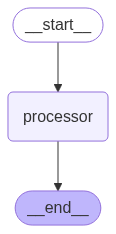

In [11]:
display(Image(app.get_graph().draw_mermaid_png()))

3. Simple sequence graph

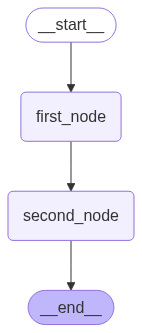

In [12]:
# from langgraph.graph import StateGraph

class AgentState(TypedDict):
    name : str
    age : str
    final : str

def first_node(state : AgentState) -> dict:
    """This is the first node of our sequence."""
    final_state = f"Hi {state['name']}!"
    return {'final' : final_state}

def second_node(state : AgentState) -> dict:
    """This is the second node of our sequence."""
    final_state = state['final'] + f"You are {state['age']} years old."
    return {'final' : final_state}

graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point("first_node")
# Для сложных графов нужно явно указывать связи между нодами с помощью рёбер по айди
graph.add_edge(start_key="first_node", end_key="second_node")
graph.set_finish_point("second_node")
app = graph.compile()
app

In [13]:
app.invoke({'name' : 'Artyom', 'age' : '22'})

{'name': 'Artyom', 'age': '22', 'final': 'Hi Artyom!You are 22 years old.'}

4. Simple branch calculator graph

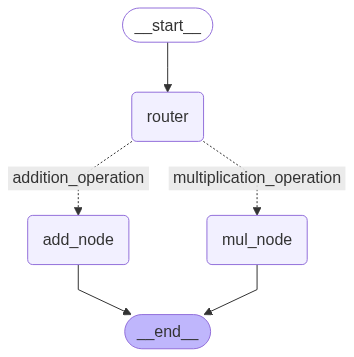

In [14]:
from math import prod
from langgraph.graph import StateGraph,START, END

class AgentState(TypedDict):
    name : str
    values : list[int]
    operations : str
    final : str

def add_node(state : AgentState) -> dict:
    """This is the node for adding values."""
    final_state = f"Hi {state['name']}! The result is {sum(state['values'])}."
    return {'final' : final_state}

def mul_node(state : AgentState) -> dict:
    """This is the node for multiplicating values."""
    final_state = f"Hi {state['name']}! The result is {prod(state['values'])}."
    return {'final' : final_state}
# роутер, опеределяет, какую ноду задействовать следующей
def decide_next_node(state : AgentState) -> dict:
    """This node decides what operation to do."""
    if state['operations'] == '*':
        return "multiplication_operation"
    else:
        return "addition_operation"

graph = StateGraph(AgentState)

graph.add_node("add_node", add_node)
graph.add_node("mul_node", mul_node)
# не изменяет стейта и не изменяет полей, это только роутер
graph.add_node("router", lambda state : {})

# можно указывать на связи так, через рёбра напрямую, а не через энти- и финишпоинты
# но нужно импортнуть старт и энд
graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        'addition_operation' : 'add_node',
        'multiplication_operation' : 'mul_node'
    }
)
graph.add_edge("add_node", END)
graph.add_edge("mul_node", END)
app = graph.compile()
app

In [15]:
res = app.invoke({'name' : "Artyom", 'values' : [1, 2, 3, 4, 5], 'operations' : '*'})
res

{'name': 'Artyom',
 'values': [1, 2, 3, 4, 5],
 'operations': '*',
 'final': 'Hi Artyom! The result is 120.'}

5. Simple looping graph

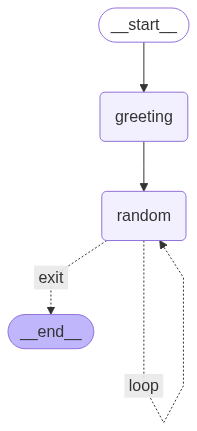

In [16]:
import random
class AgentState(TypedDict):
    name : str
    number : list[int]
    counter : int

def greeting_node(state : AgentState) -> dict:
    """A simple greeting node that starts the sequence and sets the counter."""
    initial_counter = 0
    greet = f'Hi there {state['name']}!\n'
    return {'name' : greet, 'counter' : initial_counter}

def random_node(state : AgentState) -> dict:
    """Generates a random number from 1 to 100."""
    cur_list = state.get('number', [])
    new_number = cur_list + [random.randint(1, 100)]
    new_counter = state['counter'] + 1
    return {'number' : new_number, 'counter' : new_counter}

# нода, чтобы 10 раз прокрутить лист, добавив по одному рандомному числу от 1 до 100 за раз
def should_continue(state : AgentState) -> dict:
    """Decides what to do next."""
    if state['counter'] < 10:
        print("ENTERING LOOP", state['counter'])
        return 'loop'
    else:
        return 'exit'
    
graph = StateGraph(AgentState)
graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)

graph.set_entry_point("greeting")
graph.add_edge("greeting", "random")
graph.add_conditional_edges(
                    "random",
                    should_continue,
                    {"loop" : "random",
                     "exit" : END}
)
app = graph.compile()
app

In [17]:
app.invoke({'name' : 'Artyom', 'number' : [], 'counter' : -1})

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4
ENTERING LOOP 5
ENTERING LOOP 6
ENTERING LOOP 7
ENTERING LOOP 8
ENTERING LOOP 9


{'name': 'Hi there Artyom!\n',
 'number': [2, 12, 43, 21, 38, 68, 20, 33, 76, 9],
 'counter': 10}

5. First AI agent

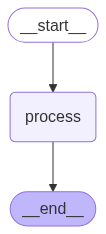

In [18]:
import os
# в отличие от SystemMessage, это сообщения, которые высылает юзер (сам запрос)
from langchain_core.messages import HumanMessage
# from langgraph.graph import StateGraph, START, END 
# from typing import TypedDict
from pprint import pprint
# нужно для хранения секретных штук типа ключей апи
from dotenv import load_dotenv
# бесплатный api provider, тем не менее, требующий апи-ключ 
from groq import Groq



load_dotenv() 
llm = Groq(
    api_key= os.getenv("GROQ_API_KEY"))


class AgentState(TypedDict):
    messages : list[HumanMessage]

def process(state : AgentState) -> dict:
    #  клиент (аутентификация, ввод апи ключа, базовый юрл 
    # -> сервис "чат" (со специфичными методами) (а может быть .images / .audio для мультимодалок)
    # -> завершения (а в чате можно делать и реранжирование, модерацию, другие таски) 
    # -> метод для создания текста (а может быть .retrieve() - получить по айди 
    # или .list() - откапывание истории сообщений)

    response = llm.chat.completions.create(
                model="openai/gpt-oss-20b",
                messages=[{"role": "user", "content": state['messages'][-1].content}],
                temperature=1,
                max_completion_tokens=1024
)
    # Ответов может быть сделано несколько, выбираем из них
    # Нам нужен сам объект "сообщение", а в нем могут быть также и роли (ассистент, система, юзер)
    # и вызов тулзов. если бы модель вызвала тул, то контент сообщения был бы пустым
    pprint(response.choices[0].message.content)
    return {}

graph = StateGraph(AgentState)
graph.add_node("process", process) 

graph.set_entry_point("process")
graph.add_edge(START, "process")
graph.add_edge("process", END)
app = graph.compile()
app

In [19]:
user_input = input("Your question: ")
while user_input != "exit":
    app.invoke({'messages' : [HumanMessage(content=user_input)]});
    user_input = input("Your question: ")

('I’m here to help! Could you let me know what you’d like to discuss or ask '
 'about?')
'Hello! 👋 How can I help you today?'
'I’m here to help! What would you like to talk about or ask?'
'Hello! I’m here to help. What can I do for you today?'
'I didn’t see a question—how can I help you today?'


6. Chat bot AI agent

In [ ]:
from typing import Union
from langchain_core.messages import AIMessage, HumanMessage
load_dotenv()
class AgentState(TypedDict):
    messages : list[Union[HumanMessage, AIMessage]]

llm = Groq(api_key= os.getenv("GROQ_API_KEY"))

def process(state : AgentState) -> dict:
    """This node will solve the request you input."""
    formatted_messages = ""
    for msg in state['messages']:
        if isinstance(msg, HumanMessage):
            formatted_messages += "\nuser: " + msg.content
        elif isinstance(msg, AIMessage):
            formatted_messages += "\nassistant: " + msg.content

    response = llm.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[{"role": "user", "content": formatted_messages}],
        temperature=1,
        max_completion_tokens=1024
    ).choices[0].message
    updated_message = state['messages'] + [AIMessage(content=response.content)]
    print(f"\n AI: {response.content}")
    return {'messages' : updated_message}

graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END)
agent = graph.compile()

conversation_history = []
user_input = input("Enter: ")
while user_input != "exit":
    conversation_history.append(HumanMessage(content=user_input))
    result = agent.invoke({'messages' : conversation_history})
    conversation_history = result['messages']
    user_input = input("Enter: ")

with open("dialog_log.txt", "w") as file:
    file.write("Your conversation Log:\n")

    for message in conversation_history:
        if isinstance(message, HumanMessage):
            file.write(f"You: {message.content}\n")
        elif isinstance(message, AIMessage):
            file.write(f"AI: {message.content}\n")
    file.write("End of conversation.\n")
    


 AI: Hey Mark! 👋 How can I help you today?


In [22]:
conversation_history

[HumanMessage(content="hi i'm mark", additional_kwargs={}, response_metadata={}),
 AIMessage(content='Hey Mark! 👋 How can I help you today?', additional_kwargs={}, response_metadata={})]

7. ReAct agent

In [106]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
# BaseMessage - базовый класс всех сообщений
# ToolMessage - возвращает аутпут тулзов обратно в ллм
# SystemMessage - системный промпт
# более удобная либа для вызова тулзов чем просто грок апи
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
# add_messages - корректная очередь сообщений (reduser)
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

load_dotenv()
# Аннотейтед - не только передача типа данных, но и объяснение контекста в метаданных
email = Annotated[str, "This should be a valid email format."]
#  Сиквенс - чтобы избежать манипуляций с листами при хранении истории диалога

class AgentState(TypedDict):
    #  умный способ хранить очередь сообщений. стейты дополняются, метадата - в add_messages
    messages : Annotated[Sequence[BaseMessage], add_messages]

# так же как в smolagents
@tool
def add(a : int, b : int):
    """This is an addition function that adds two numbers together."""

    return a + b
@tool
def substract(a : int, b : int):
    """This is an substraction function that only for two non-negative numbers, the second from the first."""

    return a - b
@tool
def multiply(a : int, b : int):
    """This is an multiplication function that multiplies two numbers."""

    return a * b
# функции передаём без вызова, по ссылке
tools=[add, substract, multiply]

# LangChain автоматически конвертирует сообщения
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY")
).bind_tools(tools)
# ChatOpenAI(model = ... ).bind_tools(tools)

# openai - like обращения. гораздо удобнее низкоуровнего грока
def model_call(state : AgentState) -> dict:
    sys_prompt = SystemMessage(content=
                "You are a useful AI assistent, please answer" \
                "using most relevant tools you have.")
    
    response = llm.invoke([sys_prompt] + state['messages'])
    return {"messages" : [response]}

# условие останова вызова тулзов
def should_continue(state : AgentState):
    messages = state['messages']
    last_message = messages[-1]
    if not last_message.tool_calls:
        return "end"
    return "continue"

graph = StateGraph(AgentState)
graph.add_node("my_math_agent", model_call)
# специальная нода вызова тулзов
tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.add_edge(START, "my_math_agent")
# переходим в эту ноду, если модель хочет
graph.add_conditional_edges(
    "my_math_agent",
    should_continue, 
    {
        "end" : END,
        "continue" : "tools"
    }
)
# и переходим обратно, когда выполнение обращения к тулзу закончено
graph.add_edge("tools", "my_math_agent")
app = graph.compile()


In [110]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()
            
inputs = {"messages": [("user", "Count 1340 + 124, then Count 14777 - 9, and Count 18891 * 38892 separately."
"Tell me a joke after answering")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Count 1340 + 124, then Count 14777 - 9, and Count 18891 * 38892 separately.Tell me a joke after answering
================================== Ai Message ==================================
Tool Calls:
  add (wpwn6h8eh)
 Call ID: wpwn6h8eh
  Args:
    a: 1340
    b: 124
  substract (gr2bszpct)
 Call ID: gr2bszpct
  Args:
    a: 14777
    b: 9
  multiply (66pj3v9sr)
 Call ID: 66pj3v9sr
  Args:
    a: 18891
    b: 38892
================================= Tool Message =================================
Name: multiply

734708772
================================== Ai Message ==================================

Why don't scientists trust atoms? Because they make up everything.


8. Drafter Agent.

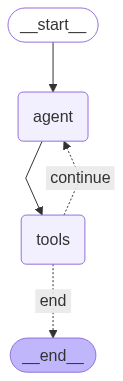

In [43]:
from typing import TypedDict, Sequence, Annotated
from dotenv import load_dotenv
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage, ToolMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
import os
load_dotenv()

# глобальная переменная чтобы хранить содержание документов
document_content = ""

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
@tool
def update(content: str) -> str:
    """Updates the document with the provided content."""
    global document_content
    document_content = content
    return f"Document has been updated successfully! The current content is:\n{document_content}"


@tool
def save(filename: str) -> str:
    """Save the current document to a text file and finish the process.
    
    Args:
        filename: Name for the text file.
    """

    global document_content

    if not filename.endswith('.txt'):
        filename = f"{filename}.txt"


    try:
        with open(filename, 'w') as file:
            file.write(document_content)
        print(f"\n💾 Document has been saved to: {filename}")
        return f"Document has been saved successfully to '{filename}'."
    
    except Exception as e:
        return f"Error saving document: {str(e)}"
    
tools = [update, save]
model = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY")
).bind_tools(tools)

def our_agent(state : AgentState) -> dict:
    system_prompt = SystemMessage(content=f"""
                    You are Drafter, a helpful writing assistant. You are going to help the user update and modify documents.
    
    - If the user wants to update or modify content, use the 'update' tool with the complete updated content.
    - If the user wants to save and finish, you need to use the 'save' tool.
    - Make sure to always show the current document state after modifications.
    
    The current document content is:{document_content}
    """)
    if not state["messages"]:
        user_input = "I'm ready to help you update a document. What would you like to create?"
        user_message = HumanMessage(content=user_input)

    else:
        user_input = input("\nWhat would you like to do with the document? ")
        print(f"\n USER: {user_input}")
        user_message = HumanMessage(content=user_input)

    all_messages = [system_prompt] + list(state["messages"]) + [user_message]

    response = model.invoke(all_messages)

    print(f"\n AI: {response.content}")
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")

    return {"messages": list(state["messages"]) + [user_message, response]}

def should_continue(state : AgentState) -> str:
    """Determine if we should continue or end the conversation."""

    messages = state['messages']

    if not messages:
        return 'continue'
    for message in reversed(messages):
        if (isinstance(message, ToolMessage) and
            "saved" in message.content.lower() and
            "document" in message.content.lower()):
            return "end"
    return "continue"

graph = StateGraph(AgentState)
graph.add_node("agent", our_agent)
graph.add_node("tools", ToolNode(tools))

graph.set_entry_point("agent")
graph.add_edge("agent","tools")

graph.add_conditional_edges(
    "tools",
    should_continue,
    {
        "continue" : "agent",
        "end" : END,
    },
)
app = graph.compile()
app

In [ ]:
def print_stream(stream):
    for message in stream:
        message.pretty_print()
def run_document_agent():
    print("\n === DRAFTER ===")
    state = {'messages': []}
    for step in app.stream(state, stream_mode='values'):
        if "messages" in step:
            print_stream(step['messages'])

    print("\n === DRAFTER FINISHED ===")

run_document_agent()


 === DRAFTER ===

 AI: We don't have a document yet, so let's start from scratch. I'd like to create a document with the title "User Guide" and the initial content "This is a sample user guide. It will be updated as we go along."

Current document content: This is a sample user guide. It will be updated as we go along.
================================ Human Message =================================

I'm ready to help you update a document. What would you like to create?
================================== Ai Message ==================================

We don't have a document yet, so let's start from scratch. I'd like to create a document with the title "User Guide" and the initial content "This is a sample user guide. It will be updated as we go along."

Current document content: This is a sample user guide. It will be updated as we go along.
================================ Human Message =================================

I'm ready to help you update a document. What would you like t

9. RAG Agent.

In [50]:
from typing import TypedDict, Sequence, Annotated
from dotenv import load_dotenv
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage, ToolMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
import os
load_dotenv()

True

In [51]:
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)
embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

No sentence-transformers model found with name sentence-transformers/all-MiniLM-L6-v2. Creating a new one with mean pooling.


In [52]:
pdf_path = "Stock_Market_Performance_2024.pdf"
if not os.path.exists(pdf_path):
    raise FileNotFoundError(f"PDF file not found: {pdf_path}")
pdf_loader = PyPDFLoader(pdf_path)
try:
    pages = pdf_loader.load()
    print(f"PDF has been loaded and has {len(pages)} pages")
except Exception as e:
    print(f"Error loading PDF: {e}")
    raise

PDF has been loaded and has 9 pages


In [53]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)
pages_split = text_splitter.split_documents(pages) 
persist_directory = r"\RAG"
collection_name = "stock_market"
if not os.path.exists(persist_directory):
    os.makedirs(persist_directory)


try:
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        persist_directory=persist_directory,
        collection_name=collection_name
    )
    print(f"Created ChromaDB vector store!")
    
except Exception as e:
    print(f"Error setting up ChromaDB: {str(e)}")
    raise

Created ChromaDB vector store!


In [54]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)
@tool
def retriever_tool(query: str) -> str:
    """
    This tool searches and returns the information from the Stock Market Performance 2024 document.
    """

    docs = retriever.invoke(query)

    if not docs:
        return "I found no relevant information in the Stock Market Performance 2024 document."
    
    results = []
    for i, doc in enumerate(docs):
        results.append(f"Document {i+1}:\n{doc.page_content}")
    
    return "\n\n".join(results)

In [55]:
tools = [retriever_tool]

llm = llm.bind_tools(tools)

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

def should_continue(state: AgentState):
    """Check if the last message contains tool calls."""
    result = state['messages'][-1]
    return hasattr(result, 'tool_calls') and len(result.tool_calls) > 0

In [56]:
system_prompt = """
You are an intelligent AI assistant who answers questions about Stock Market Performance in 2024 based on the PDF document loaded into your knowledge base.
Use the retriever tool available to answer questions about the stock market performance data. You can make multiple calls if needed.
If you need to look up some information before asking a follow up question, you are allowed to do that!
Please always cite the specific parts of the documents you use in your answers.
"""
tools_dict = {our_tool.name: our_tool for our_tool in tools}

In [57]:
def call_llm(state: AgentState) -> dict:
    """Function to call the LLM with the current state."""
    messages = list(state['messages'])
    messages = [SystemMessage(content=system_prompt)] + messages
    message = llm.invoke(messages)
    return {'messages': [message]}

def take_action(state: AgentState) -> dict:
    """Execute tool calls from the LLM's response."""

    tool_calls = state['messages'][-1].tool_calls
    results = []
    for t in tool_calls:
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query', 'No query provided')}")
        
        if not t['name'] in tools_dict: # Checks if a valid tool is present
            print(f"\nTool: {t['name']} does not exist.")
            result = "Incorrect Tool Name, Please Retry and Select tool from List of Available tools."
        
        else:
            result = tools_dict[t['name']].invoke(t['args'].get('query', ''))
            print(f"Result length: {len(str(result))}")
            

        # Appends the Tool Message
        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))

    print("Tools Execution Complete. Back to the model!")
    return {'messages': results}

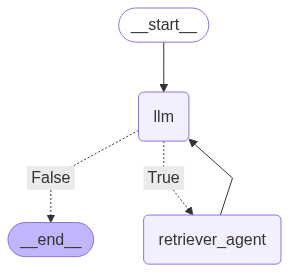

In [58]:
graph = StateGraph(AgentState)
graph.add_node("llm", call_llm)
graph.add_node("retriever_agent", take_action)

graph.add_conditional_edges(
    "llm",
    should_continue,
    {True: "retriever_agent", False: END}
)
graph.add_edge("retriever_agent", "llm")
graph.set_entry_point("llm")

rag_agent = graph.compile()
rag_agent

In [59]:
def running_agent():
    print("\n=== RAG AGENT===")
    
    while True:
        user_input = input("\nWhat is your question: ")
        if user_input.lower() in ['exit', 'quit']:
            break
            
        messages = [HumanMessage(content=user_input)] 

        result = rag_agent.invoke({"messages": messages})
        
        print("\n=== ANSWER ===")
        print(result['messages'][-1].content)


running_agent()


=== RAG AGENT===

=== ANSWER ===
It seems like you're just saying hello. If you'd like to know something about the stock market performance in 2024, I'd be happy to help. What's on your mind?
Calling Tool: retriever_tool with query: Stock Market Performance 2024 document
Result length: 4673
Tools Execution Complete. Back to the model!

=== ANSWER ===
The document describes the stock market performance in 2024, highlighting the strong gains made by the U.S. stock market, particularly in the technology sector. The S&P 500 index delivered a 25% total return for the year, with the tech-heavy Nasdaq Composite outpacing the broader market, jumping nearly 29% for the year. The "Magnificent 7" group of mega-cap technology stocks, including Apple, Microsoft, Alphabet, Amazon, Meta, Nvidia, and Tesla, collectively surged by roughly 64-67% on average in 2024 and accounted for over half of the S&P 500's return for the year.

The document also notes that the market climate was one of bullish senti